# Data Download
Put the SampleSubmission.csv, Test.csv, and Train.csv under the same directory
I put it in /Data - Lucky


In [1]:
#Import some libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pylab import rcParams
import seaborn as sb
sb.set_style('darkgrid')
rcParams['figure.figsize'] = 8,8
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

In [2]:
#import data
train = pd.read_csv('Data/Train.csv')
test=  pd.read_csv('Data/Test.csv')
submission = pd.read_csv('Data/SampleSubmission.csv')

In [3]:
train.columns, test.columns

(Index(['user_id', 'REGION', 'TENURE', 'MONTANT', 'FREQUENCE_RECH', 'REVENUE',
        'ARPU_SEGMENT', 'FREQUENCE', 'DATA_VOLUME', 'ON_NET', 'ORANGE', 'TIGO',
        'ZONE1', 'ZONE2', 'MRG', 'REGULARITY', 'TOP_PACK', 'FREQ_TOP_PACK',
        'CHURN'],
       dtype='str'),
 Index(['user_id', 'REGION', 'TENURE', 'MONTANT', 'FREQUENCE_RECH', 'REVENUE',
        'ARPU_SEGMENT', 'FREQUENCE', 'DATA_VOLUME', 'ON_NET', 'ORANGE', 'TIGO',
        'ZONE1', 'ZONE2', 'MRG', 'REGULARITY', 'TOP_PACK', 'FREQ_TOP_PACK'],
       dtype='str'))

# The Problem
(Taken from https://zindi.world/competitions/expresso-churn-prediction)


Expresso is an African telecommunications company that provides customers with airtime and mobile data bundles. The objective of this challenge is to develop a machine learning model to predict the likelihood of each Expresso customer “churning,” i.e. becoming inactive and not making any transactions for 90 days.

This solution will help Expresso to better serve their customers by understanding which customers are at risk of leaving.

Variable Definition Tables
| Variable | Description | Data type |
|---|---|---|
| REGION | Client location | object |
| TENURE | Duration in the network | object |
| MONTANT | Top-up amount | float64 |
| FREQUENCE_RECH | Number of times the customer refilled | float64 |
| REVENUE | Monthly revenue generated by the client | float64 |
| ARPU_SEGMENT | Revenue over 90 days / 3 | float64 |
| FREQUENCE | Number of times the client generated revenue | float64 |
| DATA_VOLUME | Number of connections | float64 |
| ON_NET | Calls within Expresso | float64 |
| ORANGE | Calls to Orange | float64 |
| TIGO | Calls to Tigo | float64 |
| ZONE1 | Calls to zone 1 | float64 |
| ZONE2 | Calls to zone 2 | float64 |
| MRG | Unclear definition; constant column | object |
| REGULARITY | Number of times the client is active over 90 days | int64 |
| TOP_PACK | Client’s most frequently activated pack | object |
| FREQ_TOP_PACK | Number of times the client activated the top pack | float64 |
| CHURN | Variable to predict (target) | int64 |

Details:
1. Income*: refer to how much revenue did the customer generate for the company
2. MRG^: Unclearly defined variable, after checking, it is just a constant column.

In [4]:
target = "CHURN"
X, y = train.copy(), train[target].copy()

# Drop constant columns
# dropping user_id as well for obvious reasons
# NOT Dropping target YET, just to simplify deduplication and other stuff down the line
X.drop(columns=['user_id', 'MRG'], inplace=True)


## Data Understanding

### Handling Missing Values

In [5]:
# Count missing values per column
missing_counts = X.isna().sum()
has_na_cols = missing_counts > 0

missing_counts[has_na_cols]

REGION             849299
MONTANT            756739
FREQUENCE_RECH     756739
REVENUE            726048
ARPU_SEGMENT       726048
FREQUENCE          726048
DATA_VOLUME       1060433
ON_NET             786675
ORANGE             895248
TIGO              1290016
ZONE1             1984327
ZONE2             2017224
TOP_PACK           902594
FREQ_TOP_PACK      902594
dtype: int64

In [6]:
cols_with_na = [
    'REGION',
    'MONTANT',
    'FREQUENCE_RECH',
    'REVENUE',
    'ARPU_SEGMENT',
    'FREQUENCE',
    'DATA_VOLUME',
    'ON_NET',
    'ORANGE',
    'TIGO',
    'ZONE1',
    'ZONE2',
    'TOP_PACK',
    'FREQ_TOP_PACK'
]

# Helper function
def summarize_against_label(df, col, label):
    missing = df[col].isna()
    summary = (
        pd.DataFrame({
            f'{col}_is_missing': missing,
            'CHURN': label
        }).groupby(f"{col}_is_missing")['CHURN']
        .agg(customer="size", churn_rate="mean")
    )
    return summary

# Check one by one, kinda manual, but, eh, unescapable
# Purpose: Find whether "NaN" has a meaning or actually missing
for col in cols_with_na:
    summary = summarize_against_label(X, col, y)
    print(summary)
    print("=" * 50)

# Manually check: Essentially, EVERY NA columns has some association with churn rate
# Need to validate later, but, keeping every cols for now.
na_cols_with_importance = [
    'REGION',
    'MONTANT',
    'FREQUENCE_RECH',
    'REVENUE',
    'ARPU_SEGMENT',
    'FREQUENCE',
    'DATA_VOLUME',
    'ON_NET',
    'ORANGE',
    'TIGO',
    'ZONE1', # Very many missing values, has a 0.2 correlation rate with CHURN
    'ZONE2', # Same with ZONE1
    'TOP_PACK',
    'FREQ_TOP_PACK'
]

                   customer  churn_rate
REGION_is_missing                      
False               1304749    0.018020
True                 849299    0.447987
                    customer  churn_rate
MONTANT_is_missing                      
False                1397309    0.050035
True                  756739    0.441463
                           customer  churn_rate
FREQUENCE_RECH_is_missing                      
False                       1397309    0.050035
True                         756739    0.441463
                    customer  churn_rate
REVENUE_is_missing                      
False                1428000    0.054057
True                  726048    0.450098
                         customer  churn_rate
ARPU_SEGMENT_is_missing                      
False                     1428000    0.054057
True                       726048    0.450098
                      customer  churn_rate
FREQUENCE_is_missing                      
False                  1428000    0.054057
True   

In [7]:
# is 0 used for numeric columns?
num_cols = X.select_dtypes(include=np.number).columns
for col in num_cols:
    print(f"Column {col}: {X[col].describe()['min']}")

Column MONTANT: 10.0
Column FREQUENCE_RECH: 1.0
Column REVENUE: 1.0
Column ARPU_SEGMENT: 0.0
Column FREQUENCE: 1.0
Column DATA_VOLUME: 0.0
Column ON_NET: 0.0
Column ORANGE: 0.0
Column TIGO: 0.0
Column ZONE1: 0.0
Column ZONE2: 0.0
Column REGULARITY: 1.0
Column FREQ_TOP_PACK: 1.0
Column CHURN: 0.0


In [8]:
# Deal with Missing Values
# Since each columns has some level of association:
# Numeric column -> 0
# We can use 0 here because it does indicate the user has no activity in that area, which is the assumption
# Categorical column - None
# No need for ColumnTransformer, as these are constant replacement of NaNs

# I know this includes the target column, but, no Na values in the target column, so, no worries
num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(exclude=np.number).columns

num_cols, cat_cols
X[num_cols] = X[num_cols].fillna(0)
X[cat_cols] = X[cat_cols].fillna("None")

In [9]:
# No More NaN values!
missing_counts = X.isna().sum()
has_na_cols = missing_counts > 0

missing_counts[has_na_cols]

Series([], dtype: int64)

### Any Duplicates?


In [11]:
print(f"Duplicated rows count = {X.duplicated().sum()}")
# Note -> YES, A lot of duplications. But, this are different customers...
# How does each "duplication group" compare with the churn label?

# Exact duplicates include the label; feature duplicates exclude it.
total_duplicates = X.duplicated().sum()
feature_cols = X.columns.drop(target).tolist()
duplicate_mask = X.duplicated(subset=feature_cols, keep=False)
duplicate_rows = X.loc[duplicate_mask].copy()

# Count both labels for each repeated feature combination.
duplicate_summary = (
    duplicate_rows.groupby(feature_cols, dropna=False, observed=True, sort=False)[target]
    .agg(rows="size", distinct_labels="nunique", churn_1="sum")
)
duplicate_summary["churn_0"] = duplicate_summary["rows"] - duplicate_summary["churn_1"]
conflicting_groups = duplicate_summary.loc[
    duplicate_summary["distinct_labels"] > 1
].sort_values("rows", ascending=False)

print(f"Rows in repeated feature groups (including first occurrences): {len(duplicate_rows):,}")
print(f"Repeated feature groups: {len(duplicate_summary):,}")
print(f"Groups with consistent labels: {(duplicate_summary['distinct_labels'] == 1).sum():,}")
print(f"Groups with conflicting labels: {len(conflicting_groups):,}")
print(f"Rows in conflicting groups: {conflicting_groups['rows'].sum():,}")

# Each displayed group has identical features but both CHURN=0 and CHURN=1.
display(conflicting_groups.head(10).reset_index())


Duplicated rows count = 661897
Rows in repeated feature groups (including first occurrences): 692,284
Repeated feature groups: 21,753
Groups with consistent labels: 13,119
Groups with conflicting labels: 8,634
Rows in conflicting groups: 633,275


,REGION,TENURE,MONTANT,FREQUENCE_RECH,REVENUE,ARPU_SEGMENT,FREQUENCE,DATA_VOLUME,ON_NET,ORANGE,TIGO,ZONE1,ZONE2,REGULARITY,TOP_PACK,FREQ_TOP_PACK,rows,distinct_labels,churn_1,churn_0
0,None,K > 24 month,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,None,0.0,133708,2,105059,28649
1,None,K > 24 month,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,None,0.0,72200,2,49960,22240
2,None,K > 24 month,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,None,0.0,45608,2,28196,17412
3,None,K > 24 month,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,None,0.0,31621,2,18087,13534
4,None,K > 24 month,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5,None,0.0,23153,2,12080,11073
5,None,K > 24 month,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6,None,0.0,17679,2,8544,9135
6,None,K > 24 month,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7,None,0.0,13980,2,6256,7724
7,None,K > 24 month,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8,None,0.0,10968,2,4691,6277
8,None,K > 24 month,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9,None,0.0,8761,2,3538,5223
9,None,K > 24 month,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10,None,0.0,7448,2,2827,4621


# Working Data

In [14]:
# These duplicates are irreducible noise
# What do we do with irreducible noise? Keep them all.
# CARE: Need to do hashing to ensure that isolation between train and valid sets.
train_y = X[target]
train_X = X.drop(columns=[target]).copy()
hashes = pd.util.hash_pandas_object(train_X, index=False)

test_X = test.copy()
num_cols_without_churn = test_X.select_dtypes(include=np.number).columns
test_X[num_cols_without_churn] = test_X[num_cols_without_churn].fillna(0)
test_X[cat_cols] = test_X[cat_cols].fillna("None")

len(train_X), len(hashes), len(hashes.unique())

(2154048, 2154048, 1483517)

# Exploratory Data Analysis
Let's just check around the data a bit

In [15]:
# Training data label distribution
X['CHURN'].value_counts(normalize=True)

# 18.7% has label 1. The rest has label 0.
# Despite the imbalance, there is ~400K rows with label 1
# Obviously, don't use accuracy as a metric.
# We'll probably report AUC "The evaluation metric for this challenge is Area Under the Curve (AUC)." from original submission.
# Or, we can try around with class weights. But, eh, let's see how the model performs first.
18.7/100*len(X)

402806.976

In [16]:
# Clearer view on the irreducible noise
g = y.groupby(hashes)

print(g.nunique().value_counts()) # For each hash, how many unique labels are thehre
print(g.var().mean()) # Get mean variance. Rows with 1 unique label has 0 variance.

# Explanation: Around 0.5% of the rows have conflicting labels.
# Since this is a binary classification problem, the mean variance here indicates that:
# p * (1-p) = 0.1289 --> irreducible noise among duplicate features.
print(f"Irreducible noise rows ratio: {8634 / (1474883 + 8634):.4f}")

CHURN
1    1474883
2       8634
Name: count, dtype: int64
0.12889918151635607
Irreducible noise rows ratio: 0.0058


In [17]:
corr = X[num_cols].corr(method="spearman")
corr.style.background_gradient(cmap='coolwarm')

,MONTANT,FREQUENCE_RECH,REVENUE,ARPU_SEGMENT,FREQUENCE,DATA_VOLUME,ON_NET,ORANGE,TIGO,ZONE1,ZONE2,REGULARITY,FREQ_TOP_PACK,CHURN
MONTANT,1.000000,0.967862,0.984710,0.985074,0.950003,0.469241,0.751966,0.840618,0.669293,0.209906,0.225801,0.804861,0.917547,-0.444721
FREQUENCE_RECH,0.967862,1.000000,0.955316,0.955662,0.972496,0.457633,0.746147,0.817527,0.645226,0.191712,0.211568,0.796937,0.932022,-0.447782
REVENUE,0.984710,0.955316,1.000000,0.999635,0.963829,0.473307,0.756160,0.846877,0.672493,0.211046,0.226224,0.810161,0.922096,-0.448988
ARPU_SEGMENT,0.985074,0.955662,0.999635,1.000000,0.963285,0.473429,0.756089,0.846903,0.672582,0.211087,0.226332,0.810012,0.922443,-0.448979
FREQUENCE,0.950003,0.972496,0.963829,0.963285,1.000000,0.465764,0.732153,0.811716,0.640149,0.194203,0.221126,0.802615,0.913607,-0.450403
DATA_VOLUME,0.469241,0.457633,0.473307,0.473429,0.465764,1.000000,0.229490,0.251695,0.233599,0.057516,0.106994,0.426799,0.456912,-0.228314
ON_NET,0.751966,0.746147,0.756160,0.756089,0.732153,0.229490,1.000000,0.766741,0.594901,0.166762,0.105664,0.705441,0.736953,-0.410278
ORANGE,0.840618,0.817527,0.846877,0.846903,0.811716,0.251695,0.766741,1.000000,0.693889,0.192717,0.152555,0.698710,0.795322,-0.404956
TIGO,0.669293,0.645226,0.672493,0.672582,0.640149,0.233599,0.594901,0.693889,1.000000,0.149892,0.107524,0.566113,0.630965,-0.298603
ZONE1,0.209906,0.191712,0.211046,0.211087,0.194203,0.057516,0.166762,0.192717,0.149892,1.000000,0.082976,0.170887,0.178580,-0.084601


In [18]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    table = pd.crosstab(x, y) # Same as groupby([x, y]).size().unstack(), needed by chi2_contingency
    chi2 = chi2_contingency(table)[0]
    n = table.to_numpy().sum()
    return np.sqrt(chi2 / (n * (min(table.shape) - 1))) # 0 = No drift, 1 = fully determined

print("Count of categories") # Checking, because chi2 is sensitive to number of categories (biased as number of categories increases)
for col in cat_cols:
    print(col, train_X[col].nunique())

print("\nCramer's V values for categorical features:")
for col in cat_cols:
    print(col, round(cramers_v(train_X[col], train_y), 3))

print("\nCramer's V values for categorical features (excluding 'None'):")
for check_col in cat_cols:
    mask = train_X[check_col] != "None"
    print(check_col, round(cramers_v(train_X.loc[mask, check_col], train_y[mask]), 3))

# So: The signals are coming from the "None" instead of the values themselves.

Count of categories
REGION 15
TENURE 8
TOP_PACK 141

Cramer's V values for categorical features:
REGION 0.538
TENURE 0.05
TOP_PACK 0.446

Cramer's V values for categorical features (excluding 'None'):
REGION 0.035
TENURE 0.05
TOP_PACK 0.098


## Comparing Feature Distribution

CHURN                     0                   1       
                       mean  median        mean median
MONTANT         4326.059606  1800.0  394.083815    0.0
FREQUENCE_RECH     9.029883     4.0    0.759650    0.0
REVENUE         4404.871181  1819.0  397.636275    0.0
ARPU_SEGMENT    1468.295098   606.0  132.546665    0.0
FREQUENCE         11.167054     6.0    1.034070    0.0
DATA_VOLUME     2020.208588     0.0  361.671239    0.0
ON_NET           214.569852     8.0   10.381768    0.0
ORANGE            67.699080     9.0    4.048370    0.0
TIGO              11.251595     0.0    0.683551    0.0
ZONE1              0.748803     0.0    0.188598    0.0
ZONE2              0.556992     0.0    0.145312    0.0
REGULARITY        33.182215    34.0    5.777349    2.0
FREQ_TOP_PACK      6.511096     2.0    0.517931    0.0


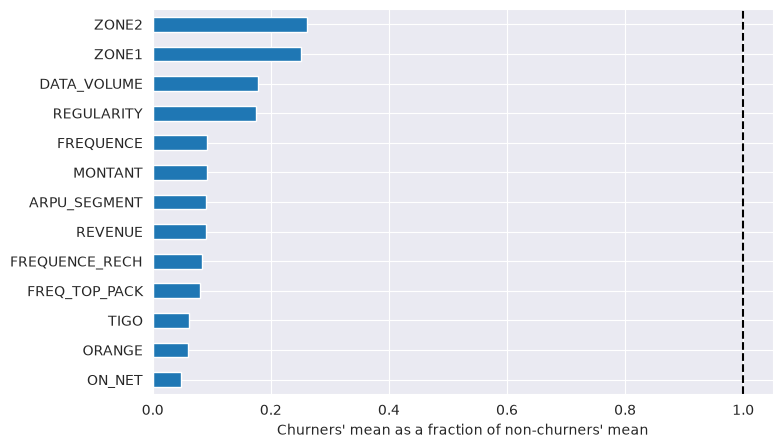

In [19]:
# Train with churn 0 vs churn 1
# Numeric features: Drift in mean and median
num_report = train_X[num_cols_without_churn].groupby(train_y).agg(["mean", "median"]).T.unstack()

import matplotlib.pyplot as plt

print(num_report)

means = num_report.xs("mean", axis=1, level=1)      # columns: 0 and 1

ratio = (means[1] / means[0]).sort_values()
ax = ratio.plot.barh(figsize=(8, 5))
ax.axvline(1, color="black", linestyle="--")
ax.set_xlabel("Churners' mean as a fraction of non-churners' mean")
plt.show()

# No obvious IDENTICAL distribution. Maybe Zone1 and Zone2? But, eh, for now... yeah.
# There's some obvious drifts that do indicate importance though.

In [20]:
# Categorical: share of each category within churn 0 and churn 1
for col in cat_cols:
    shares = pd.crosstab(train_X[col], train_y, normalize="columns")
    shares["gap"] = (shares[1] - shares[0]).abs()
    print(shares.sort_values("gap", ascending=False).head(10))

# For Region: If there's a None value, the user is very unlikely to be churned
# For Tenure: Not exactly different between churn vs non-churn. This is probably one of the safest thing to drop. 
#             Also make sense --> People can stop using your service at any time, really.
# For TOP_PACK: "None" seems to be the strongest signal, All-net 500F=2000F;5d comes 2nd (large gap, but most doesn't churn, just shows that it is a popular pack)


CHURN               0         1       gap
REGION                                   
None         0.267890  0.941802  0.673913
DAKAR        0.287646  0.024439  0.263207
THIES        0.101206  0.007265  0.093941
SAINT-LOUIS  0.067635  0.003763  0.063873
LOUGA        0.055697  0.003911  0.051786
KAOLACK      0.054120  0.005626  0.048493
DIOURBEL     0.037159  0.004654  0.032506
TAMBACOUNDA  0.030986  0.002094  0.028892
KAFFRINE     0.024940  0.000782  0.024158
KOLDA        0.021900  0.001032  0.020868
CHURN                 0         1       gap
TENURE                                     
K > 24 month   0.953573  0.926738  0.026836
I 18-21 month  0.018817  0.030563  0.011746
H 15-18 month  0.010904  0.017139  0.006236
G 12-15 month  0.005822  0.011666  0.005845
J 21-24 month  0.005592  0.007273  0.001680
F 9-12 month   0.004050  0.005545  0.001495
E 6-9 month    0.000870  0.000782  0.000088
D 3-6 month    0.000372  0.000295  0.000077
CHURN                                             0     

In [21]:
# Train and Test
# Numeric features: Drift in mean and median
rows = []
for col in num_cols_without_churn:
    a, b = train_X[col], test_X[col]
    rows.append({
        "feature": col,
        "train_mean": a.mean(), "test_mean": b.mean(),
        "train_median": a.median(), "test_median": b.median(),
    })
num_report = pd.DataFrame(rows).set_index("feature")

# Categorical features: difference in category proportions
rows = []
for col in cat_cols:
    p = train_X[col].value_counts(normalize=True)
    q = test_X[col].value_counts(normalize=True)
    gap = p.subtract(q, fill_value=0).abs()
    rows.append({
        "feature": col,
        "largest_gap_category": gap.idxmax(),
        "largest_gap": gap.max(),
    })
cat_report = pd.DataFrame(rows).set_index("feature")

# Manual check: No meaning drift in numeric features
# For categorical features, even the largest gap is only at 0.13%, so, the distribution should be somewhat similar?
num_report, cat_report

(                 train_mean    test_mean  train_median  test_median
 feature                                                            
 MONTANT         3588.627955  3591.069898        1000.0       1000.0
 FREQUENCE_RECH     7.478823     7.487584           2.0          2.0
 REVENUE         3653.324883  3656.846888        1000.0       1000.0
 ARPU_SEGMENT    1217.779015  1218.952700         333.0        333.0
 FREQUENCE          9.266639     9.280927           3.0          3.0
 DATA_VOLUME     1709.154299  1699.662305           0.0          0.0
 ON_NET           176.274917   177.212429           3.0          3.0
 ORANGE            55.761558    55.818808           3.0          3.0
 TIGO               9.269586     9.286039           0.0          0.0
 ZONE1              0.643738     0.641378           0.0          0.0
 ZONE2              0.479782     0.484862           0.0          0.0
 REGULARITY        28.042505    28.081699          24.0         24.0
 FREQ_TOP_PACK      5.387094     5